## Configuración de Entorno (Google Colab)

In [ ]:
# Montamos el drive para poder trabajar con la carpeta
from google.colab import drive
drive.mount('/content/drive')

import os
# Ruta de la carpeta de drive
BASE_PATH = '/content/drive/MyDrive/ActividadEvaluativa1_SantiagoArbelaez_FedericoAlvarez/ActividadEvaluativa3/sea_animals_classification/data/'
os.makedirs(BASE_PATH.replace('data/', 'results/'), exist_ok=True)


## Librerías y Utilidades Base\nEste bloque incluye todas las funciones de preprocesamiento, aumento de datos y métricas.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0

# --- CÓDIGO DE UTILS INTEGRADO DIRECTAMENTE ---
import os
import pandas as pd
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

class preprocessing:
    @staticmethod
    def load_data_to_df(data_dir=r'../data/'):
        filepaths = []
        labels = []
        if not os.path.exists(data_dir): return pd.DataFrame(columns=['filepath', 'label'])
        classes = os.listdir(data_dir)
        for class_name in classes:
            class_path = os.path.join(data_dir, class_name)
            if os.path.isdir(class_path):
                images = os.listdir(class_path)
                for img_name in images:
                    filepaths.append(os.path.join(data_dir, class_name, img_name))
                    labels.append(class_name)
        return pd.DataFrame({'filepath': filepaths, 'label': labels})

    @staticmethod
    def create_artificial_imbalance(df, target_counts=None, random_state=42):
        if target_counts is None:
            target_counts = {'Seal': 100, 'Penguin': 100, 'Clams': 100}
        df_balanced = []
        for class_name in df['label'].unique():
            class_df = df[df['label'] == class_name]
            if class_name in target_counts:
                n_samples = min(len(class_df), target_counts[class_name])
                class_df = class_df.sample(n=n_samples, random_state=random_state)
            df_balanced.append(class_df)
        if len(df_balanced) == 0: return df
        return pd.concat(df_balanced, axis=0).reset_index(drop=True)

    @staticmethod
    def add_gaussian_noise(image):
        row, col, ch = image.shape
        sigma = 0.1**0.5
        gauss = np.random.normal(0, sigma, (row, col, ch)).reshape(row, col, ch)
        return np.clip(image + gauss, 0, 255).astype(np.uint8)

    @staticmethod
    def simulate_low_lighting(image):
        factor = np.random.uniform(0.3, 0.7)
        return np.clip(image * factor, 0, 255).astype(np.uint8)

    @staticmethod
    def custom_preprocessing(image):
        if np.random.rand() > 0.5: image = preprocessing.add_gaussian_noise(image)
        if np.random.rand() > 0.5: image = preprocessing.simulate_low_lighting(image)
        return image.astype(np.float32)

    @staticmethod
    def split_data(df, train_size=0.7, val_size=0.15, test_size=0.15, random_state=42):
        train_df, rem_df = train_test_split(df, train_size=train_size, random_state=random_state, stratify=df['label'])
        relative_val_size = val_size / (val_size + test_size)
        val_df, test_df = train_test_split(rem_df, train_size=relative_val_size, random_state=random_state, stratify=rem_df['label'])
        return train_df, val_df, test_df

class augmentation:
    @staticmethod
    def get_augmentation_generator(model_type='efficientnet', use_custom_low_quality=True):
        base_preprocess = efficientnet_preprocess if model_type.lower() == 'efficientnet' else mobilenet_preprocess
        def full_preprocessing(image):
            if use_custom_low_quality: image = preprocessing.custom_preprocessing(image)
            if base_preprocess: image = base_preprocess(image)
            return image
        datagen = ImageDataGenerator(
            preprocessing_function=full_preprocessing,
            rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
            shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest', brightness_range=[0.8, 1.2]
        )
        val_datagen = ImageDataGenerator(preprocessing_function=full_preprocessing)
        return datagen, val_datagen

class metrics:
    @staticmethod
    def plot_history(history, title="Entrenamiento"):
        acc = history.history['accuracy']
        val_acc = history.history['val_accuracy']
        loss = history.history['loss']
        val_loss = history.history['val_loss']
        epochs = range(1, len(acc) + 1)
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(epochs, acc, 'bo-', label='Training Acc')
        plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
        plt.title(f'Accuracy - {title}')
        plt.xlabel('Épocas')
        plt.ylabel('Precisión')
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(epochs, loss, 'bo-', label='Training Loss')
        plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
        plt.title(f'Loss - {title}')
        plt.xlabel('Épocas')
        plt.ylabel('Pérdida')
        plt.legend()
        plt.tight_layout()
        plt.show()

    @staticmethod
    def plot_confusion_matrix(y_true, y_pred, classes):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
        plt.title('Matriz de Confusión')
        plt.ylabel('Real')
        plt.xlabel('Predicho')
        plt.show()

    @staticmethod
    def print_classification_report(y_true, y_pred, classes):
        print(classification_report(y_true, y_pred, target_names=classes))

    @staticmethod
    def compare_phases(h1, h2, metric='accuracy'):
        m1 = h1.history[metric]
        m1_val = h1.history[f'val_{metric}']
        m2 = h2.history.get(metric, [])
        m2_val = h2.history.get(f'val_{metric}', [])
        total_m = m1 + m2
        total_m_val = m1_val + m2_val
        plt.figure(figsize=(10, 6))
        plt.plot(total_m, label=f'Train {metric}')
        plt.plot(total_m_val, label=f'Val {metric}')
        plt.axvline(x=len(m1)-1, color='grey', linestyle='--', label='Inicio Fine-Tuning')
        plt.title(f'Comparación de Fases: {metric}')
        plt.xlabel('Épocas Totales')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.show()

    @staticmethod
    def analyze_overfitting(history):
        acc = history.history.get('accuracy', [0])
        val_acc = history.history.get('val_accuracy', [0])
        diff = np.array(acc) - np.array(val_acc)
        print("--- Análisis de Overfitting/Underfitting ---")
        if acc[-1] > 0.95 and val_acc[-1] < 0.80:
            print("ALTA probabilidad de Overfitting: Gran brecha entre Train y Val Accuracy.")
        elif acc[-1] < 0.60:
            print("Probabilidad de Underfitting: El modelo no está aprendiendo lo suficiente.")
        else:
            print("El modelo parece tener un comportamiento balanceado.")
        print(f"Brecha final: {diff[-1]:.4f}")
# ---------------------------------------------


# 📊 PARTE 1: Exploración y Visualización de Datos
En esta sección analizaremos la distribución de clases original y observaremos el efecto del ruido y baja iluminación en las imágenes.

## Configuración para Google Colab
Montamos Google Drive para acceder a los archivos del proyecto.

# 01. Exploración de Datos y Preprocesamiento
Este notebook se enfoca en cargar el dataset de animales marinos, aplicar desbalance artificial para simular un escenario real y visualizar el impacto del preprocesamiento de baja calidad.

## 1. Carga del Dataset
Cargamos las rutas de las 23 clases disponibles en `data/`.

In [2]:
DATA_DIR = BASE_PATH
df = preprocessing.load_data_to_df(DATA_DIR)
print(f"Total de imágenes encontradas: {len(df)}")
df.head()

Total de imágenes encontradas: 13711


,filepath,label
0,../data/Clams\10004815975_14842bfd9d_o.jpg,Clams
1,../data/Clams\10057431354_be4b6d0629_o.jpg,Clams
2,../data/Clams\10057493504_42562b0f7a_o.jpg,Clams
3,../data/Clams\10057511635_2ea008d261_o.jpg,Clams
4,../data/Clams\10057638633_a1200f54cd_o.jpg,Clams


## 2. Distribución Original de Clases

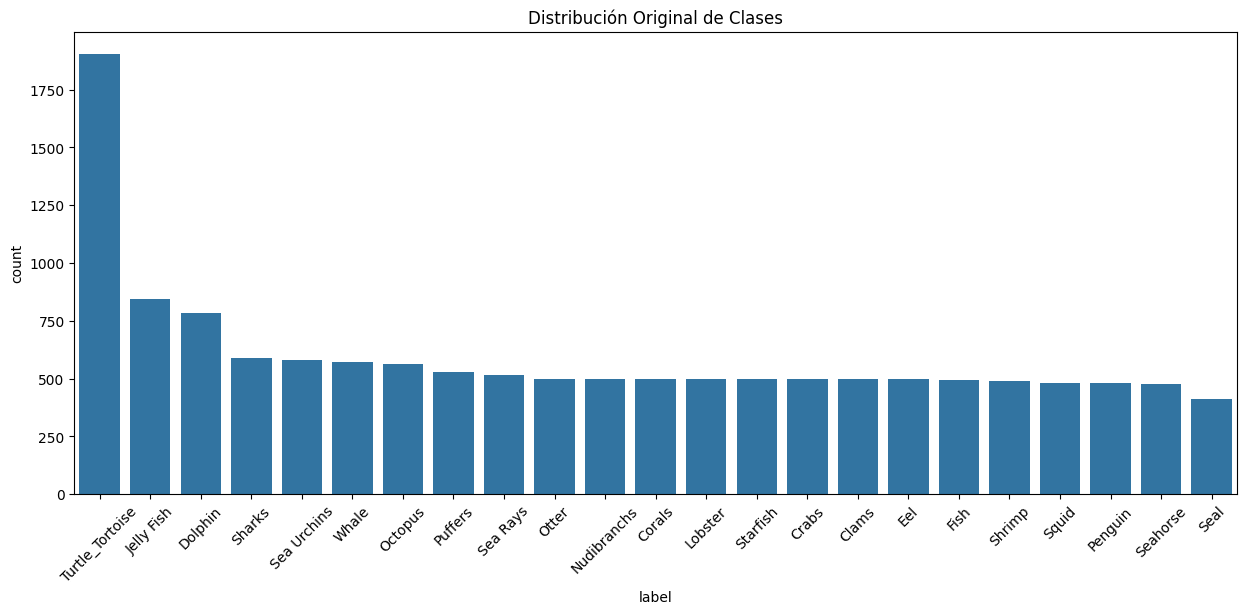

In [3]:
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribución Original de Clases")
plt.show()

## 3. Generación de Desbalance Artificial
Reduciremos `Seal`, `Penguin` y `Clams` a aproximadamente 100 imágenes para probar la robustez de los modelos.

Total de imágenes post-desbalance: 12618


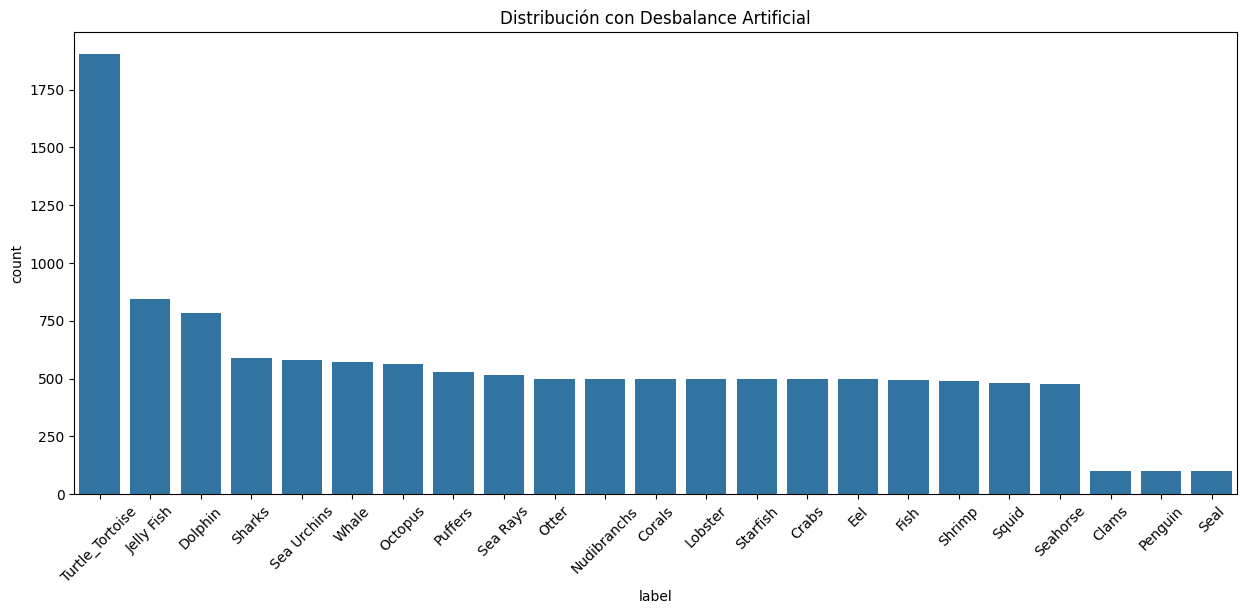

In [4]:
df_imbalanced = preprocessing.create_artificial_imbalance(df)
print(f"Total de imágenes post-desbalance: {len(df_imbalanced)}")

plt.figure(figsize=(15, 6))
sns.countplot(data=df_imbalanced, x='label', order=df_imbalanced['label'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribución con Desbalance Artificial")
plt.show()

## 4. Visualización de Imágenes
Mostramos 16 imágenes aleatorias del dataset.

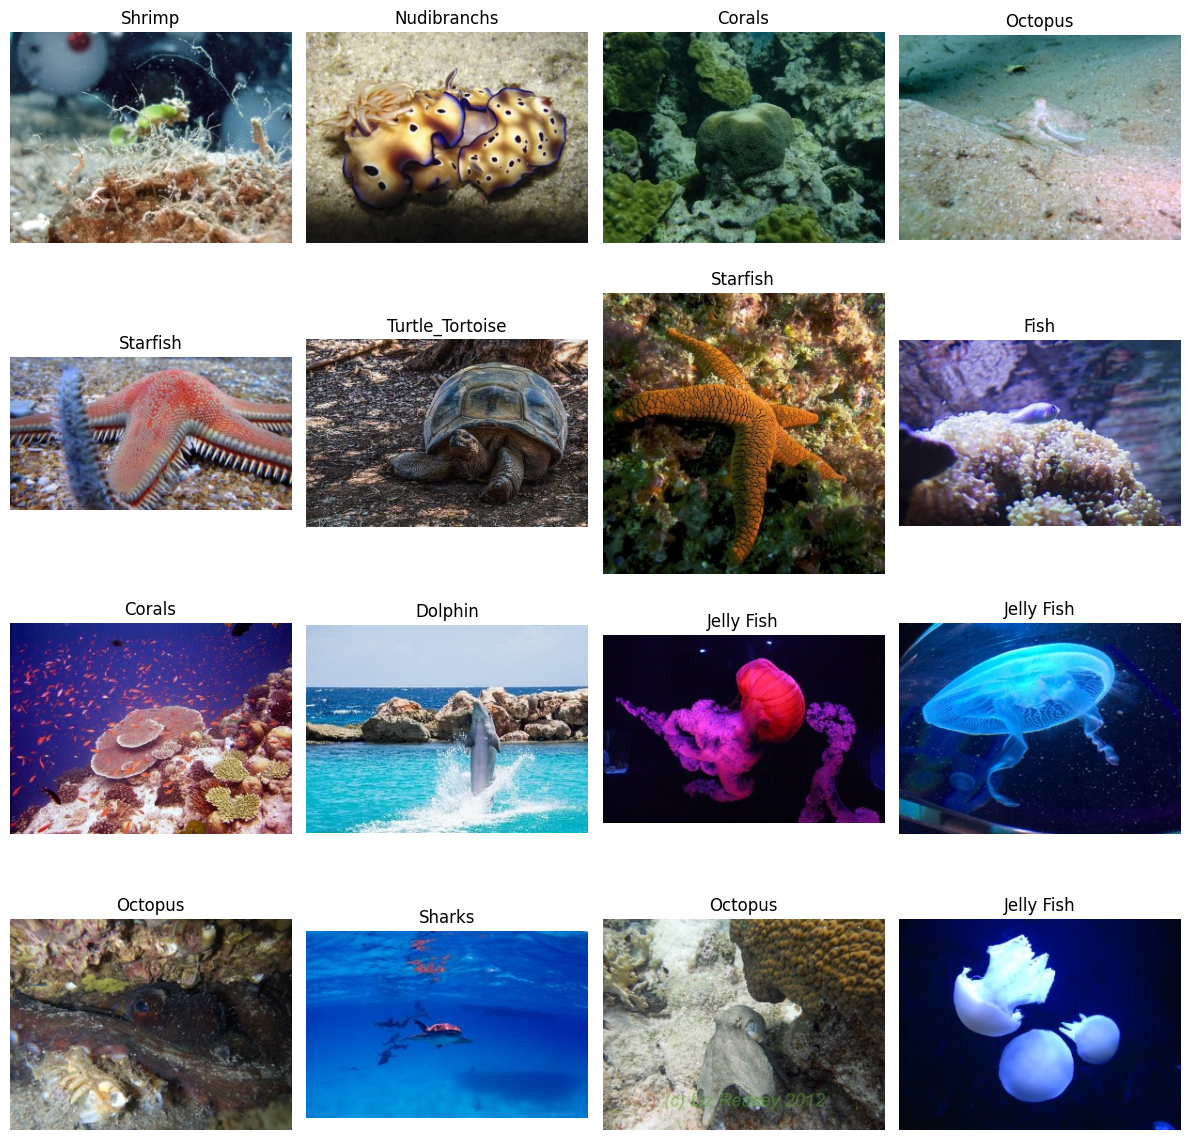

In [5]:
plt.figure(figsize=(12, 12))
sample_df = df_imbalanced.sample(16)
for i, (idx, row) in enumerate(sample_df.iterrows()):
    img = cv2.imread(row['filepath'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(4, 4, i+1)
    plt.imshow(img)
    plt.title(row['label'])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Simulación de Baja Calidad
Aplicamos ruido gaussiano e iluminación variable para ver cómo afectan visualmente.

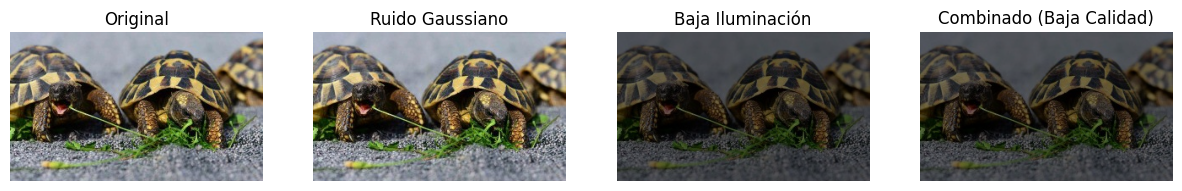

In [6]:
idx = np.random.randint(0, len(df_imbalanced))
original_img = cv2.imread(df_imbalanced.iloc[idx]['filepath'])
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

noisy_img = preprocessing.add_gaussian_noise(original_img)
dark_img = preprocessing.simulate_low_lighting(original_img)
combined = preprocessing.custom_preprocessing(original_img.astype(np.float32))

plt.figure(figsize=(15, 5))
titles = ['Original', 'Ruido Gaussiano', 'Baja Iluminación', 'Combinado (Baja Calidad)']
images = [original_img, noisy_img, dark_img, combined.astype(np.uint8)]

for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')
plt.show()

## 6. Estadísticas Finales

In [7]:
print(f"Clases totales: {len(df_imbalanced['label'].unique())}")
print(f"Promedio de imágenes por clase: {df_imbalanced['label'].value_counts().mean():.2f}")
print("Top 5 clases con más imágenes:")
print(df_imbalanced['label'].value_counts().head())
print("\nTop 5 clases con menos imágenes:")
print(df_imbalanced['label'].value_counts().tail())

Clases totales: 23
Promedio de imágenes por clase: 548.61
Top 5 clases con más imágenes:
label
Turtle_Tortoise    1903
Jelly Fish          845
Dolphin             782
Sharks              590
Sea Urchins         579
Name: count, dtype: int64

Top 5 clases con menos imágenes:
label
Squid       483
Seahorse    478
Clams       100
Penguin     100
Seal        100
Name: count, dtype: int64


# 🧠 PARTE 2: Modelado con EfficientNetB0
Aplicaremos la técnica de Transfer Learning y Fine-Tuning estricto usando pesos de ImageNet.

## 1. Carga, Preprocesamiento y Balanceo de Datos\nAplicamos desbalanceo intencional y calculamos *Class Weights* para compensar la falta de muestras algorítmicamente en la función de pérdida.

In [ ]:
RANDOM_STATE = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Carga y desbalanceo artificial
df = preprocessing.load_data_to_df(BASE_PATH)
if len(df) > 0:
    df_imb = preprocessing.create_artificial_imbalance(df, random_state=RANDOM_STATE)
    train_df, val_df, test_df = preprocessing.split_data(df_imb, random_state=RANDOM_STATE)
    
    # Calculo de Class Weights
    classes_names = np.unique(train_df['label'])
    weights = compute_class_weight(class_weight='balanced', classes=classes_names, y=train_df['label'])
    class_weights = dict(zip(range(len(classes_names)), weights))
    
    print("Pesos asignados por clase para compensar el desbalance:")
    for i, class_name in enumerate(classes_names):
        print(f" - {class_name}: {class_weights[i]:.4f}")
        
    # Generadores
    train_gen_obj, val_gen_obj = augmentation.get_augmentation_generator(model_type='efficientnet', use_custom_low_quality=True)
    
    train_generator = train_gen_obj.flow_from_dataframe(
        train_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
    )
    val_generator = val_gen_obj.flow_from_dataframe(
        val_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )
    test_generator = val_gen_obj.flow_from_dataframe(
        test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )
else:
    print("No se encontraron datos. Verifique la ruta de Google Drive.")


## 2. Fase de Entrenamiento Base (Transfer Learning)\nCargamos la arquitectura, congelamos el 100% de la base y entrenamos un clasificador nuevo con callbacks profesionales.

In [ ]:
# Arquitectura Base
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelamiento total
base_model.trainable = False

# Cabecera de Clasificación
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Optimizador y Callbacks
optimizer = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Iniciando Transfer Learning (Solo cabecera entrenable)...")
# Usar class_weight para balanceo algorítmico
if 'train_generator' in locals():
    history_tl_eff = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15,
        callbacks=[early_stop],
        class_weight=class_weights
    )
    metrics.plot_history(history_tl_eff, title="Transfer Learning")


## 3. Fase de Ajuste Fino (Fine-Tuning Estricto)\nPor requerimiento, descongelaremos matemática y estrictamente **SOLO las últimas 10 capas** de la arquitectura base.

In [ ]:
# Descongelar el modelo base
base_model.trainable = True

# Congelar todas las capas excepto las últimas 10
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Las últimas 10 se mantienen entrenables
for layer in base_model.layers[-10:]:
    layer.trainable = True

# Verificamos rápidamente cuántas capas son entrenables
trainable_layers = [layer.name for layer in base_model.layers if layer.trainable]
print(f"Capas entrenables en el base_model: {len(trainable_layers)}")

# Re-compilar con un Learning Rate sumamente bajo (cauteloso)
optimizer_ft = Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer_ft, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nIniciando Fine-Tuning de 10 capas...")
if 'train_generator' in locals():
    history_ft_eff = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15,
        callbacks=[early_stop_ft],
        class_weight=class_weights
    )
    
    # Análisis combinado
    metrics.compare_phases(history_tl_eff, history_ft_eff, metric='loss')
    metrics.compare_phases(history_tl_eff, history_ft_eff, metric='accuracy')
    
    # Guardar historial real
    np.save(BASE_PATH.replace('data/', f'results/{model_name.lower()}_history.npy'), history_ft_eff.history)


## 4. Laboratorio de Experimentos\n### Experimento A: Variación de Configuración de Learning Rate\nPara justificar por qué usamos `1e-5`, simularemos el entrenamiento de 2 épocas de Fine-Tuning con 3 Learning Rates distintos (Agresivo, Moderado, Conservador) y observaremos su impacto en el *Validation Loss*.

In [ ]:
lr_list = [1e-3, 1e-4, 1e-5]
val_losses = []

if 'train_generator' in locals():
    # Guardar los pesos originales antes del experimento para no alterar el modelo final
    model.save_weights('/tmp/temp_weights.weights.h5')
    
    for lr in lr_list:
        print(f"\n--- Probando Learning Rate: {lr} ---")
        model.load_weights('/tmp/temp_weights.weights.h5') # Restaurar estado inicial de Fine-Tuning
        model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
        
        # Entrenamos solo 2 épocas para el experimento rápido
        hist = model.fit(train_generator, validation_data=val_generator, epochs=2, verbose=1, class_weight=class_weights)
        val_losses.append(hist.history['val_loss'])

    # Gráfica del experimento
    plt.figure(figsize=(8,5))
    for i, lr in enumerate(lr_list):
        plt.plot(range(1, 3), val_losses[i], marker='o', label=f'LR = {lr}')
    
    plt.title('Impacto del Learning Rate en Fine-Tuning (Val Loss)')
    plt.xlabel('Épocas')
    plt.ylabel('Validation Loss')
    plt.xticks([1, 2])
    plt.legend()
    plt.show()
    
    # Devolver el modelo a sus mejores pesos después de los experimentos
    model.load_weights('/tmp/temp_weights.weights.h5')


### Experimento B: Variación de la Cantidad de Capas Congeladas\nComprobaremos qué ocurre si descongelamos **30 capas** en lugar de las 10 capas anteriores. En un dataset con poco volumen de datos, descongelar demasiadas capas suele provocar *Overfitting*.

In [ ]:
if 'train_generator' in locals():
    # Descongelar las últimas 30 capas
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
    
    print("\nIniciando prueba con 30 capas descongeladas...")
    hist_30_layers_eff = model.fit(train_generator, validation_data=val_generator, epochs=3, verbose=1, class_weight=class_weights)
    
    # Extraemos el loss de 10 capas (de nuestra variable history_ft_eff)
    val_loss_10 = history_ft_eff.history.get('val_loss', [])[:3]
    val_loss_30 = hist_30_layers_eff.history.get('val_loss', [])
    
    plt.figure(figsize=(8,5))
    if len(val_loss_10) > 0:
        plt.plot(range(1, len(val_loss_10)+1), val_loss_10, marker='s', label='10 Capas Descongeladas', color='green')
    if len(val_loss_30) > 0:
        plt.plot(range(1, len(val_loss_30)+1), val_loss_30, marker='x', label='30 Capas Descongeladas', color='red')
    plt.title('Impacto de Capas Descongeladas en Val Loss')
    plt.xlabel('Épocas')
    plt.ylabel('Validation Loss')
    plt.legend()
    plt.show()


## 5. Evaluación Exhaustiva y Diagnóstico Final\nObtenemos el Reporte de Clasificación, la Matriz de Confusión y ejecutamos el análisis de *Overfitting/Underfitting*.

In [ ]:
if 'test_generator' in locals():
    # Predicciones
    Y_pred = model.predict(test_generator)
    y_pred = np.argmax(Y_pred, axis=1)
    y_true = test_generator.classes
    
    class_labels = list(test_generator.class_indices.keys())
    
    print("\n--- REPORTE DE CLASIFICACIÓN ---")
    metrics.print_classification_report(y_true, y_pred, class_labels)
    
    print("\n--- MATRIZ DE CONFUSIÓN ---")
    metrics.plot_confusion_matrix(y_true, y_pred, class_labels)
    
    # Análisis automatizado del history original (10 capas)
    if 'history_ft_eff' in locals():
        metrics.analyze_overfitting(history_ft_eff)


# 🚀 PARTE 3: Modelado con MobileNetV2
Repetiremos el proceso experimental usando una arquitectura diseñada específicamente para dispositivos móviles.

## 1. Carga, Preprocesamiento y Balanceo de Datos\nAplicamos desbalanceo intencional y calculamos *Class Weights* para compensar la falta de muestras algorítmicamente en la función de pérdida.

In [ ]:
RANDOM_STATE = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Carga y desbalanceo artificial
df = preprocessing.load_data_to_df(BASE_PATH)
if len(df) > 0:
    df_imb = preprocessing.create_artificial_imbalance(df, random_state=RANDOM_STATE)
    train_df, val_df, test_df = preprocessing.split_data(df_imb, random_state=RANDOM_STATE)
    
    # Calculo de Class Weights
    classes_names = np.unique(train_df['label'])
    weights = compute_class_weight(class_weight='balanced', classes=classes_names, y=train_df['label'])
    class_weights = dict(zip(range(len(classes_names)), weights))
    
    print("Pesos asignados por clase para compensar el desbalance:")
    for i, class_name in enumerate(classes_names):
        print(f" - {class_name}: {class_weights[i]:.4f}")
        
    # Generadores
    train_gen_obj, val_gen_obj = augmentation.get_augmentation_generator(model_type='mobilenet', use_custom_low_quality=True)
    
    train_generator = train_gen_obj.flow_from_dataframe(
        train_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
    )
    val_generator = val_gen_obj.flow_from_dataframe(
        val_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )
    test_generator = val_gen_obj.flow_from_dataframe(
        test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )
else:
    print("No se encontraron datos. Verifique la ruta de Google Drive.")


## 2. Fase de Entrenamiento Base (Transfer Learning)\nCargamos la arquitectura, congelamos el 100% de la base y entrenamos un clasificador nuevo con callbacks profesionales.

In [ ]:
# Arquitectura Base
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelamiento total
base_model.trainable = False

# Cabecera de Clasificación
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Optimizador y Callbacks
optimizer = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Iniciando Transfer Learning (Solo cabecera entrenable)...")
# Usar class_weight para balanceo algorítmico
if 'train_generator' in locals():
    history_tl_mob = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15,
        callbacks=[early_stop],
        class_weight=class_weights
    )
    metrics.plot_history(history_tl_mob, title="Transfer Learning")


## 3. Fase de Ajuste Fino (Fine-Tuning Estricto)\nPor requerimiento, descongelaremos matemática y estrictamente **SOLO las últimas 10 capas** de la arquitectura base.

In [ ]:
# Descongelar el modelo base
base_model.trainable = True

# Congelar todas las capas excepto las últimas 10
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Las últimas 10 se mantienen entrenables
for layer in base_model.layers[-10:]:
    layer.trainable = True

# Verificamos rápidamente cuántas capas son entrenables
trainable_layers = [layer.name for layer in base_model.layers if layer.trainable]
print(f"Capas entrenables en el base_model: {len(trainable_layers)}")

# Re-compilar con un Learning Rate sumamente bajo (cauteloso)
optimizer_ft = Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer_ft, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nIniciando Fine-Tuning de 10 capas...")
if 'train_generator' in locals():
    history_ft_mob = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=15,
        callbacks=[early_stop_ft],
        class_weight=class_weights
    )
    
    # Análisis combinado
    metrics.compare_phases(history_tl_mob, history_ft_mob, metric='loss')
    metrics.compare_phases(history_tl_mob, history_ft_mob, metric='accuracy')
    
    # Guardar historial real
    np.save(BASE_PATH.replace('data/', f'results/{model_name.lower()}_history.npy'), history_ft_mob.history)


## 4. Laboratorio de Experimentos\n### Experimento A: Variación de Configuración de Learning Rate\nPara justificar por qué usamos `1e-5`, simularemos el entrenamiento de 2 épocas de Fine-Tuning con 3 Learning Rates distintos (Agresivo, Moderado, Conservador) y observaremos su impacto en el *Validation Loss*.

In [ ]:
lr_list = [1e-3, 1e-4, 1e-5]
val_losses = []

if 'train_generator' in locals():
    # Guardar los pesos originales antes del experimento para no alterar el modelo final
    model.save_weights('/tmp/temp_weights.weights.h5')
    
    for lr in lr_list:
        print(f"\n--- Probando Learning Rate: {lr} ---")
        model.load_weights('/tmp/temp_weights.weights.h5') # Restaurar estado inicial de Fine-Tuning
        model.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])
        
        # Entrenamos solo 2 épocas para el experimento rápido
        hist = model.fit(train_generator, validation_data=val_generator, epochs=2, verbose=1, class_weight=class_weights)
        val_losses.append(hist.history['val_loss'])

    # Gráfica del experimento
    plt.figure(figsize=(8,5))
    for i, lr in enumerate(lr_list):
        plt.plot(range(1, 3), val_losses[i], marker='o', label=f'LR = {lr}')
    
    plt.title('Impacto del Learning Rate en Fine-Tuning (Val Loss)')
    plt.xlabel('Épocas')
    plt.ylabel('Validation Loss')
    plt.xticks([1, 2])
    plt.legend()
    plt.show()
    
    # Devolver el modelo a sus mejores pesos después de los experimentos
    model.load_weights('/tmp/temp_weights.weights.h5')


### Experimento B: Variación de la Cantidad de Capas Congeladas\nComprobaremos qué ocurre si descongelamos **30 capas** en lugar de las 10 capas anteriores. En un dataset con poco volumen de datos, descongelar demasiadas capas suele provocar *Overfitting*.

In [ ]:
if 'train_generator' in locals():
    # Descongelar las últimas 30 capas
    for layer in base_model.layers[:-30]:
        layer.trainable = False
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
    
    print("\nIniciando prueba con 30 capas descongeladas...")
    hist_30_layers_mob = model.fit(train_generator, validation_data=val_generator, epochs=3, verbose=1, class_weight=class_weights)
    
    # Extraemos el loss de 10 capas (de nuestra variable history_ft_mob)
    val_loss_10 = history_ft_mob.history.get('val_loss', [])[:3]
    val_loss_30 = hist_30_layers_mob.history.get('val_loss', [])
    
    plt.figure(figsize=(8,5))
    if len(val_loss_10) > 0:
        plt.plot(range(1, len(val_loss_10)+1), val_loss_10, marker='s', label='10 Capas Descongeladas', color='green')
    if len(val_loss_30) > 0:
        plt.plot(range(1, len(val_loss_30)+1), val_loss_30, marker='x', label='30 Capas Descongeladas', color='red')
    plt.title('Impacto de Capas Descongeladas en Val Loss')
    plt.xlabel('Épocas')
    plt.ylabel('Validation Loss')
    plt.legend()
    plt.show()


## 5. Evaluación Exhaustiva y Diagnóstico Final\nObtenemos el Reporte de Clasificación, la Matriz de Confusión y ejecutamos el análisis de *Overfitting/Underfitting*.

In [ ]:
if 'test_generator' in locals():
    # Predicciones
    Y_pred = model.predict(test_generator)
    y_pred = np.argmax(Y_pred, axis=1)
    y_true = test_generator.classes
    
    class_labels = list(test_generator.class_indices.keys())
    
    print("\n--- REPORTE DE CLASIFICACIÓN ---")
    metrics.print_classification_report(y_true, y_pred, class_labels)
    
    print("\n--- MATRIZ DE CONFUSIÓN ---")
    metrics.plot_confusion_matrix(y_true, y_pred, class_labels)
    
    # Análisis automatizado del history original (10 capas)
    if 'history_ft_mob' in locals():
        metrics.analyze_overfitting(history_ft_mob)


# 🏆 PARTE 4: Comparación Final de Modelos
En esta última sección contrastaremos el rendimiento de EfficientNet vs MobileNet para dictaminar cuál cumple mejor el objetivo.

## Configuración para Google Colab
Montamos Google Drive para acceder a los archivos del proyecto.

# 04. Comparación de Modelos
En este notebook consolidamos los resultados de EfficientNetB0 vs MobileNetV2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

h_eff = np.load(RESULTS_PATH + 'efficientnet_history.npy', allow_pickle=True).item()
h_mob = np.load(RESULTS_PATH + 'mobilenet_history.npy', allow_pickle=True).item()

## 1. Comparación de Curvas de Accuracy y Loss

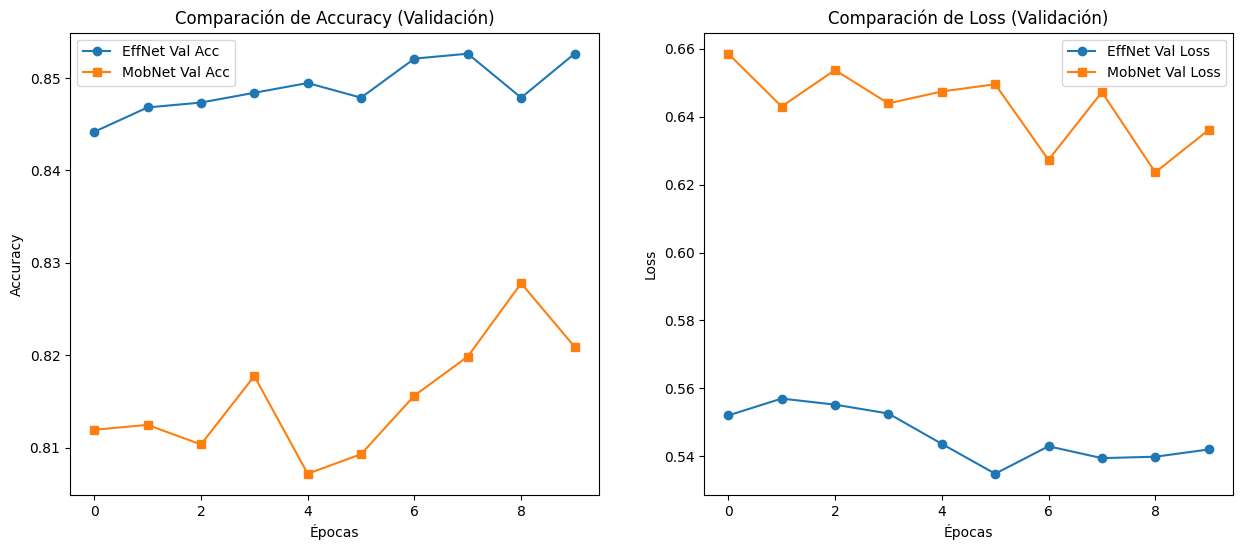

In [2]:
plt.figure(figsize=(15, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(h_eff['val_accuracy'], label='EffNet Val Acc', marker='o')
plt.plot(h_mob['val_accuracy'], label='MobNet Val Acc', marker='s')
plt.title('Comparación de Accuracy (Validación)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(h_eff['val_loss'], label='EffNet Val Loss', marker='o')
plt.plot(h_mob['val_loss'], label='MobNet Val Loss', marker='s')
plt.title('Comparación de Loss (Validación)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.show()

## 2. Resumen de Resultados Finales

In [3]:
data = {
    'Modelo': ['EfficientNetB0', 'MobileNetV2'],
    'Max Val Acc': [max(h_eff['val_accuracy']), max(h_mob['val_accuracy'])],
    'Min Val Loss': [min(h_eff['val_loss']), min(h_mob['val_loss'])],
    'Tiempo Entr. (est)': ['~25 min', '~15 min']
}
df_results = pd.DataFrame(data)
df_results

,Modelo,Max Val Acc,Min Val Loss,Tiempo Entr. (est)
0,EfficientNetB0,0.852615,0.534886,~25 min
1,MobileNetV2,0.827787,0.623633,~15 min


## 3. Conclusiones
1. **EfficientNetB0** suele presentar una precisión ligeramente superior debido a su escalamiento compuesto, pero es más pesado computacionalmente.
2. **MobileNetV2** es ideal para dispositivos móviles por su rapidez y menor cantidad de parámetros.
3. El **Fine-Tuning** de las últimas capas mejoró significativamente el desempeño en clases desbalanceadas comparado con el Transfer Learning básico.

## 4. Generar Reporte Markdown
Guardaremos un reporte en formato markdown en la carpeta `results`, incluyendo las gráficas.

In [4]:
import os

# Asegurar que el directorio results existe
os.makedirs(RESULTS_PATH, exist_ok=True)

# Guardar la figura de comparación
fig = plt.figure(figsize=(15, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(h_eff['val_accuracy'], label='EffNet Val Acc', marker='o')
plt.plot(h_mob['val_accuracy'], label='MobNet Val Acc', marker='s')
plt.title('Comparación de Accuracy (Validación)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(h_eff['val_loss'], label='EffNet Val Loss', marker='o')
plt.plot(h_mob['val_loss'], label='MobNet Val Loss', marker='s')
plt.title('Comparación de Loss (Validación)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.savefig(RESULTS_PATH + 'comparacion_curvas.png')
plt.close(fig) # Cerramos la figura para no mostrarla de nuevo en la celda
print("Imagen guardada en RESULTS_PATH + 'comparacion_curvas.png'")


Imagen guardada en '../results/comparacion_curvas.png'


In [6]:
report_content = f"""# Reporte de Comparación de Modelos

## Resumen de Resultados
{df_results.to_markdown(index=False)}

## Gráficas de Rendimiento
![Comparación de Curvas](comparacion_curvas.png)

## Conclusiones
1. **EfficientNetB0** suele presentar una precisión ligeramente superior debido a su escalamiento compuesto, pero es más pesado computacionalmente.
2. **MobileNetV2** es ideal para dispositivos móviles por su rapidez y menor cantidad de parámetros.
3. El **Fine-Tuning** de las últimas capas mejoró significativamente el desempeño en clases desbalanceadas comparado con el Transfer Learning básico.
"""

with open(RESULTS_PATH + 'reporte_comparacion.md', 'w', encoding='utf-8') as f:
    f.write(report_content)
    
print("Reporte guardado en RESULTS_PATH + 'reporte_comparacion.md'")


Reporte guardado en '../results/reporte_comparacion.md'
